In [6]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/nalisha/tesla-ea-deliveries-and-production-data20152025/tesla_deliveries_dataset_2015_2025.csv


In [1]:

# Data manipulation
import pandas as pd
import numpy as np

# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import (
    train_test_split,
    cross_val_score,
    GridSearchCV
)

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

# Evaluation Metrics
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# Time Series
from statsmodels.tsa.stattools import adfuller

# Ignore unnecessary warnings
import warnings
warnings.filterwarnings("ignore")

# Plot styling
plt.style.use("ggplot")
sns.set_theme(style="whitegrid")

print("All libraries imported successfully!")

All libraries imported successfully!


In [7]:

#Load the Dataset

dataset_path = "/kaggle/input/datasets/nalisha/tesla-ea-deliveries-and-production-data20152025/tesla_deliveries_dataset_2015_2025.csv"

df = pd.read_csv(dataset_path)

print("✅ Dataset loaded successfully!")

✅ Dataset loaded successfully!


In [8]:

#  Sample Records

print("First 5 Rows")
display(df.head())

print("\nLast 5 Rows")
display(df.tail())

First 5 Rows


,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations
0,2023,5,Europe,Model S,17646,17922,92874.27,120,704,1863.42,Interpolated (Month),12207
1,2015,2,Asia,Model X,3797,4164,62205.65,75,438,249.46,Official (Quarter),7640
2,2019,1,North America,Model X,8411,9189,117887.32,82,480,605.59,Interpolated (Month),14071
3,2021,2,North America,Model 3,6555,7311,89294.91,120,712,700.07,Official (Quarter),9333
4,2016,12,Middle East,Model Y,12374,13537,114846.78,120,661,1226.88,Estimated (Region),8722



Last 5 Rows


,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations
2635,2021,10,Middle East,Model Y,13488,14333,113771.10,120,719,1454.68,Official (Quarter),4273
2636,2019,7,Middle East,Model S,18300,18407,81889.67,82,487,1336.81,Official (Quarter),9833
2637,2019,9,Asia,Model S,13291,14839,97139.38,100,580,1156.32,Estimated (Region),13709
2638,2020,5,Asia,Cybertruck,3471,3714,69990.57,60,358,186.39,Interpolated (Month),6754
2639,2018,8,North America,Model S,2639,2929,51676.24,82,474,187.63,Estimated (Region),14297


In [9]:

# Dataset Shape

rows, columns = df.shape

print(f"Number of Rows    : {rows}")
print(f"Number of Columns : {columns}")

Number of Rows    : 2640
Number of Columns : 12


In [10]:

# Column Names


print("Columns in the Dataset:\n")

for i, column in enumerate(df.columns, start=1):
    print(f"{i}. {column}")

Columns in the Dataset:

1. Year
2. Month
3. Region
4. Model
5. Estimated_Deliveries
6. Production_Units
7. Avg_Price_USD
8. Battery_Capacity_kWh
9. Range_km
10. CO2_Saved_tons
11. Source_Type
12. Charging_Stations


In [11]:

# Dataset Information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2640 entries, 0 to 2639
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Year                  2640 non-null   int64  
 1   Month                 2640 non-null   int64  
 2   Region                2640 non-null   object 
 3   Model                 2640 non-null   object 
 4   Estimated_Deliveries  2640 non-null   int64  
 5   Production_Units      2640 non-null   int64  
 6   Avg_Price_USD         2640 non-null   float64
 7   Battery_Capacity_kWh  2640 non-null   int64  
 8   Range_km              2640 non-null   int64  
 9   CO2_Saved_tons        2640 non-null   float64
 10  Source_Type           2640 non-null   object 
 11  Charging_Stations     2640 non-null   int64  
dtypes: float64(2), int64(7), object(3)
memory usage: 247.6+ KB


In [12]:

# Statistical Summary

display(df.describe(include="all"))

,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations
count,2640.000000,2640.000000,2640,2640,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640,2640.000000
unique,NaN,NaN,4,5,NaN,NaN,NaN,NaN,NaN,NaN,3,NaN
top,NaN,NaN,Europe,Model S,NaN,NaN,NaN,NaN,NaN,NaN,Interpolated (Month),NaN
freq,NaN,NaN,660,528,NaN,NaN,NaN,NaN,NaN,NaN,884,NaN
mean,2020.000000,6.500000,NaN,NaN,9922.199621,10655.847348,84907.340330,87.059470,500.257576,744.076989,NaN,8932.133712
std,3.162877,3.452707,NaN,NaN,3935.950093,4260.600858,20123.258036,20.836265,120.868549,353.221224,NaN,3469.565883
min,2015.000000,1.000000,NaN,NaN,48.000000,50.000000,50003.700000,60.000000,330.000000,3.070000,NaN,3002.000000
25%,2017.000000,3.750000,NaN,NaN,7292.000000,7828.250000,67726.365000,75.000000,418.000000,499.620000,NaN,5897.750000
50%,2020.000000,6.500000,NaN,NaN,9857.000000,10546.500000,85058.510000,82.000000,470.000000,699.515000,NaN,8901.500000
75%,2023.000000,9.250000,NaN,NaN,12510.250000,13469.000000,102373.042500,100.000000,586.250000,943.765000,NaN,11938.000000


In [13]:
# Missing Values

missing_values = df.isnull().sum()

print("Missing Values in Each Column:\n")
display(missing_values)

Missing Values in Each Column:



Year                    0
Month                   0
Region                  0
Model                   0
Estimated_Deliveries    0
Production_Units        0
Avg_Price_USD           0
Battery_Capacity_kWh    0
Range_km                0
CO2_Saved_tons          0
Source_Type             0
Charging_Stations       0
dtype: int64

In [14]:
# Duplicate Records

duplicate_rows = df.duplicated().sum()

print(f"Total Duplicate Rows: {duplicate_rows}")

Total Duplicate Rows: 0


In [15]:

# Data Types
display(df.dtypes)

Year                      int64
Month                     int64
Region                   object
Model                    object
Estimated_Deliveries      int64
Production_Units          int64
Avg_Price_USD           float64
Battery_Capacity_kWh      int64
Range_km                  int64
CO2_Saved_tons          float64
Source_Type              object
Charging_Stations         int64
dtype: object

In [16]:

# Unique Values in Each Column

for column in df.columns:
    print(f"\n{column}")
    print(f"Unique Values: {df[column].nunique()}")


Year
Unique Values: 11

Month
Unique Values: 12

Region
Unique Values: 4

Model
Unique Values: 5

Estimated_Deliveries
Unique Values: 2401

Production_Units
Unique Values: 2430

Avg_Price_USD
Unique Values: 2638

Battery_Capacity_kWh
Unique Values: 5

Range_km
Unique Values: 219

CO2_Saved_tons
Unique Values: 2599

Source_Type
Unique Values: 3

Charging_Stations
Unique Values: 2389


# Dataset Inspection & Initial Observations

The Tesla Deliveries and Production dataset was successfully loaded and inspected to understand its overall structure and quality before performing any preprocessing or machine learning tasks.

# Dataset Overview
- Total Records (Rows): **2,640**
- Total Features (Columns): **12**
- Numerical Features: **9**
- Categorical Features: **3**
- Memory Usage: **247.6 KB**

# Data Quality Assessment
- No missing values were found in any column.
- No duplicate records were detected.
- All columns have appropriate data types.
- Therefore, no immediate data cleaning is required for missing values or duplicate removal.

# Feature Summary
The dataset contains the following information:
- Temporal Features: **Year, Month**
- Categorical Features: **Region, Model, Source_Type**
- Production & Sales Features:
  - Estimated_Deliveries (Target Variable)
  - Production_Units
  - Avg_Price_USD
  - Battery_Capacity_kWh
  - Range_km
  - CO2_Saved_tons
  - Charging_Stations

# Unique Values Analysis
- Year contains **11** unique values.
- Month contains **12** unique values.
- Region contains **4** categories.
- Model contains **5** Tesla vehicle models.
- Source_Type contains **3** data source categories.
- The remaining numerical features contain a large number of unique values, indicating continuous numerical data suitable for regression analysis.

# Conclusion
The dataset is complete, clean, and well-structured. Since no missing values or duplicate records were found and all data types are appropriate, the dataset is ready for exploratory data analysis (EDA), feature engineering, and machine learning model development.

# 4. Data Cleaning

Data cleaning is a crucial preprocessing step that ensures the dataset is accurate, consistent, and suitable for machine learning.

The following checks are performed:
- Create a working copy of the dataset
- Verify missing values
- Check duplicate records
- Validate data types
- Inspect categorical values
- Verify numerical ranges
- Prepare the cleaned dataset for Exploratory Data Analysis (EDA)

In [18]:

# Create Working Copy

df_clean = df.copy()

print("Working copy created successfully.")
print("Shape:", df_clean.shape)

Working copy created successfully.
Shape: (2640, 12)


In [19]:
# Verify Missing Values

missing_values = df_clean.isnull().sum()

display(missing_values)

print("\nTotal Missing Values:", missing_values.sum())

Year                    0
Month                   0
Region                  0
Model                   0
Estimated_Deliveries    0
Production_Units        0
Avg_Price_USD           0
Battery_Capacity_kWh    0
Range_km                0
CO2_Saved_tons          0
Source_Type             0
Charging_Stations       0
dtype: int64


Total Missing Values: 0


In [20]:
# Verify Duplicate Records
duplicate_rows = df_clean.duplicated().sum()
print("Duplicate Rows:", duplicate_rows)

Duplicate Rows: 0


In [21]:
#  Verify Data Types
display(df_clean.dtypes)

Year                      int64
Month                     int64
Region                   object
Model                    object
Estimated_Deliveries      int64
Production_Units          int64
Avg_Price_USD           float64
Battery_Capacity_kWh      int64
Range_km                  int64
CO2_Saved_tons          float64
Source_Type              object
Charging_Stations         int64
dtype: object

In [22]:
# Numerical Range Validation
numeric_columns = df_clean.select_dtypes(include=["int64", "float64"]).columns
display(df_clean[numeric_columns].describe().T)

,count,mean,std,min,25%,50%,75%,max
Year,2640.0,2020.000000,3.162877,2015.00,2017.000,2020.000,2023.0000,2025.00
Month,2640.0,6.500000,3.452707,1.00,3.750,6.500,9.2500,12.00
Estimated_Deliveries,2640.0,9922.199621,3935.950093,48.00,7292.000,9857.000,12510.2500,25704.00
Production_Units,2640.0,10655.847348,4260.600858,50.00,7828.250,10546.500,13469.0000,28939.00
Avg_Price_USD,2640.0,84907.340330,20123.258036,50003.70,67726.365,85058.510,102373.0425,119965.36
Battery_Capacity_kWh,2640.0,87.059470,20.836265,60.00,75.000,82.000,100.0000,120.00
Range_km,2640.0,500.257576,120.868549,330.00,418.000,470.000,586.2500,719.00
CO2_Saved_tons,2640.0,744.076989,353.221224,3.07,499.620,699.515,943.7650,2548.55
Charging_Stations,2640.0,8932.133712,3469.565883,3002.00,5897.750,8901.500,11938.0000,14996.00


In [23]:
# Inspect Categories

categorical_columns = df_clean.select_dtypes(include="object").columns
for column in categorical_columns:
    print("="*50)
    print(f"{column}")
    print("="*50)
    print(df_clean[column].value_counts())
    print()

Region
Region
Europe           660
Asia             660
North America    660
Middle East      660
Name: count, dtype: int64

Model
Model
Model S       528
Model X       528
Model 3       528
Model Y       528
Cybertruck    528
Name: count, dtype: int64

Source_Type
Source_Type
Interpolated (Month)    884
Official (Quarter)      884
Estimated (Region)      872
Name: count, dtype: int64



In [24]:
# Final Dataset Shape
print("Final Dataset Shape:", df_clean.shape)

Final Dataset Shape: (2640, 12)


## Data Cleaning Observations

The dataset was successfully validated before analysis.

### Key Findings

- A working copy of the dataset was created to preserve the original data.
- No missing values were found in any feature.
- No duplicate records were detected.
- All data types were already correctly assigned.
- Numerical features contain realistic values without obvious inconsistencies.
- Categorical features contain well-defined categories without unexpected values.

### Conclusion

The dataset is clean, complete, and consistent. No additional cleaning operations such as missing value imputation, duplicate removal, or data type conversion were required. The cleaned dataset is now ready for Exploratory Data Analysis (EDA) and feature engineering.

#  Exploratory Data Analysis (EDA)

Exploratory Data Analysis (EDA) is performed to understand the dataset through statistical summaries and visualizations before building machine learning models.

The objectives of EDA are:
- Understand the distribution of numerical features.
- Analyze relationships between variables.
- Identify trends and patterns.
- Detect potential outliers.
- Generate insights that will support feature engineering and model selection.

In [25]:
# Summary Statistics
display(df_clean.describe().T)

,count,mean,std,min,25%,50%,75%,max
Year,2640.0,2020.000000,3.162877,2015.00,2017.000,2020.000,2023.0000,2025.00
Month,2640.0,6.500000,3.452707,1.00,3.750,6.500,9.2500,12.00
Estimated_Deliveries,2640.0,9922.199621,3935.950093,48.00,7292.000,9857.000,12510.2500,25704.00
Production_Units,2640.0,10655.847348,4260.600858,50.00,7828.250,10546.500,13469.0000,28939.00
Avg_Price_USD,2640.0,84907.340330,20123.258036,50003.70,67726.365,85058.510,102373.0425,119965.36
Battery_Capacity_kWh,2640.0,87.059470,20.836265,60.00,75.000,82.000,100.0000,120.00
Range_km,2640.0,500.257576,120.868549,330.00,418.000,470.000,586.2500,719.00
CO2_Saved_tons,2640.0,744.076989,353.221224,3.07,499.620,699.515,943.7650,2548.55
Charging_Stations,2640.0,8932.133712,3469.565883,3002.00,5897.750,8901.500,11938.0000,14996.00


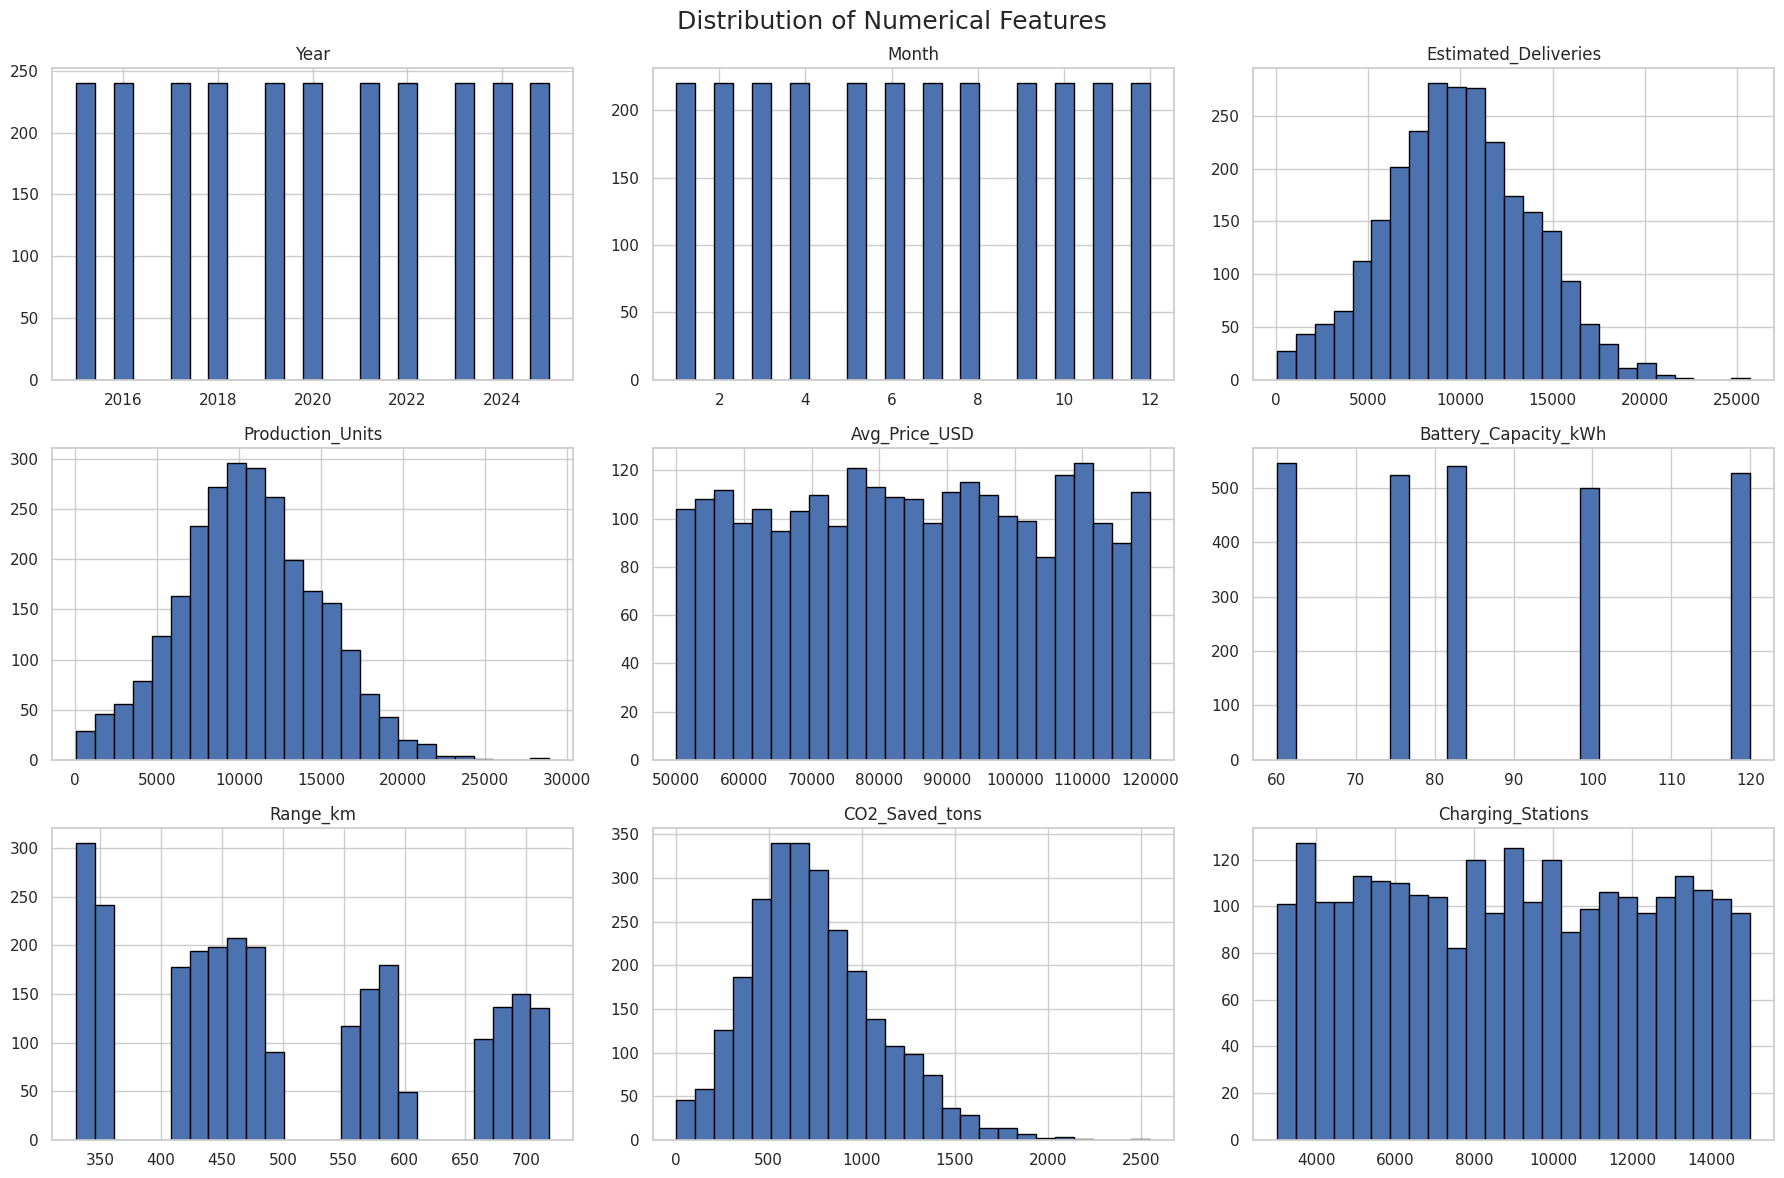

In [26]:
# Distribution of Numerical Features
numeric_columns = df_clean.select_dtypes(include=['int64','float64']).columns

df_clean[numeric_columns].hist(
    figsize=(18,12),
    bins=25,
    edgecolor="black"
)

plt.suptitle("Distribution of Numerical Features", fontsize=18)

plt.tight_layout()

plt.show()

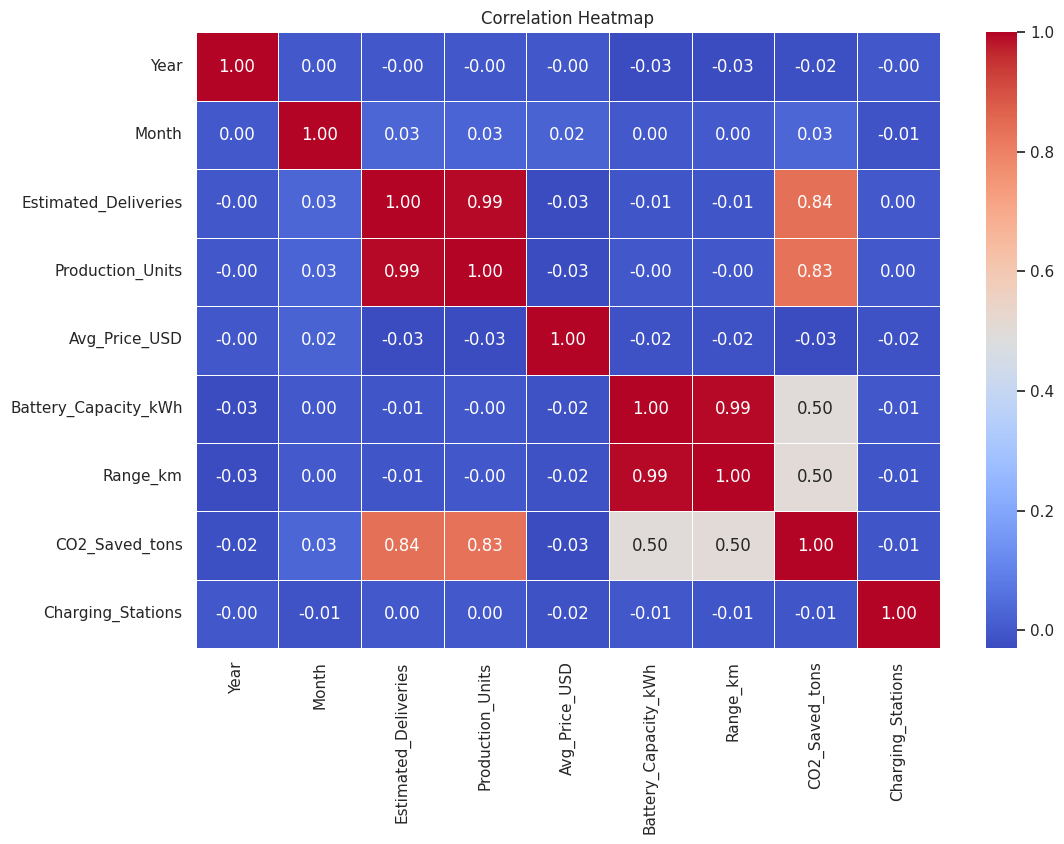

In [27]:
# Correlation Heatmap
plt.figure(figsize=(12,8))

correlation = df_clean.select_dtypes(include=['int64','float64']).corr()

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5
)

plt.title("Correlation Heatmap")

plt.show()

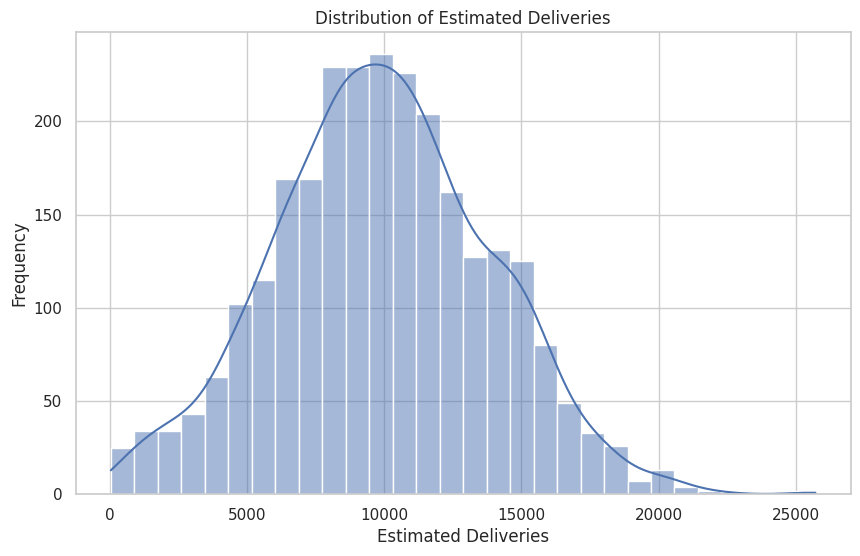

In [28]:
# Target Distribution
plt.figure(figsize=(10,6))

sns.histplot(
    df_clean["Estimated_Deliveries"],
    bins=30,
    kde=True
)

plt.title("Distribution of Estimated Deliveries")

plt.xlabel("Estimated Deliveries")

plt.ylabel("Frequency")

plt.show()

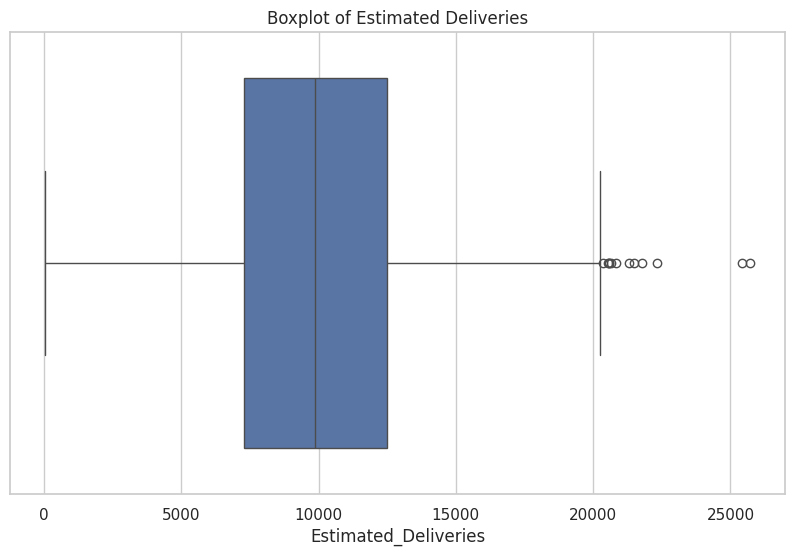

In [29]:
#  Outlier Detection
plt.figure(figsize=(10,6))

sns.boxplot(
    x=df_clean["Estimated_Deliveries"]
)

plt.title("Boxplot of Estimated Deliveries")

plt.show()

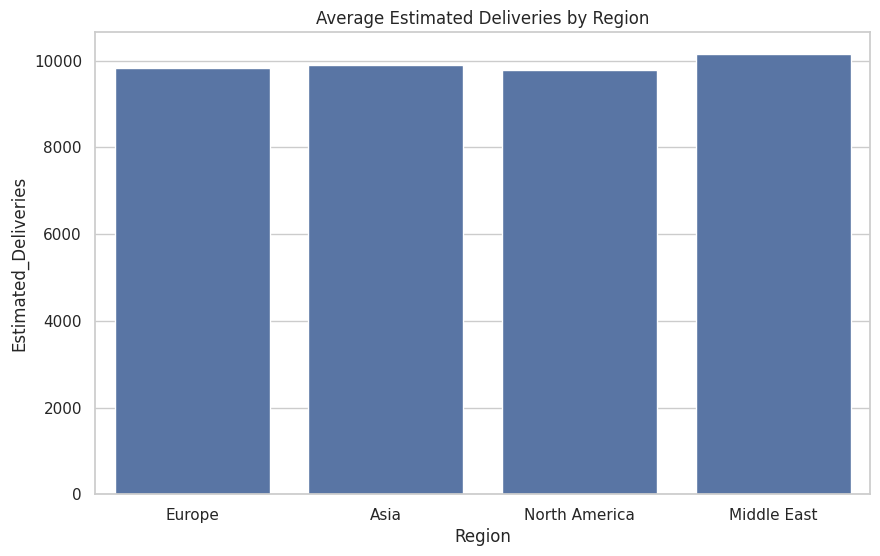

In [30]:
#  Region Analysis
plt.figure(figsize=(10,6))

sns.barplot(
    data=df_clean,
    x="Region",
    y="Estimated_Deliveries",
    estimator="mean",
    errorbar=None
)

plt.title("Average Estimated Deliveries by Region")

plt.show()

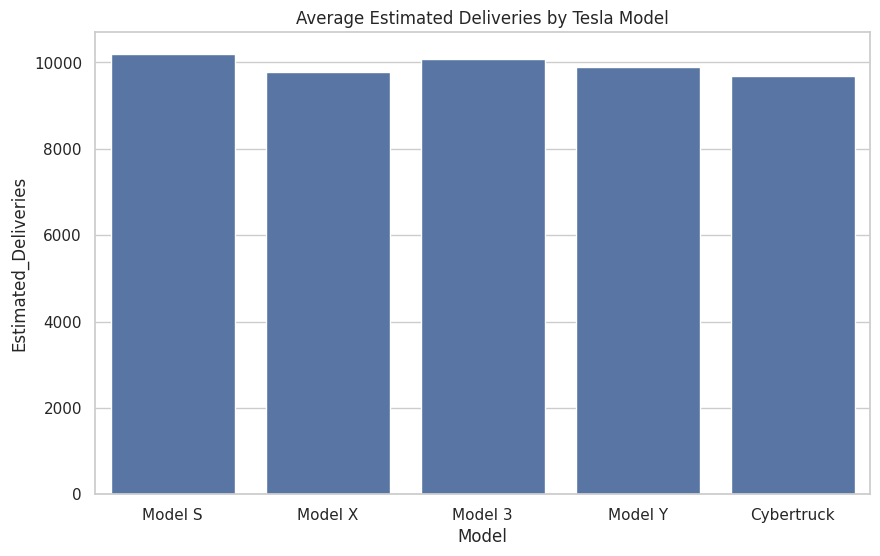

In [31]:
#  Model Analysis
plt.figure(figsize=(10,6))

sns.barplot(
    data=df_clean,
    x="Model",
    y="Estimated_Deliveries",
    estimator="mean",
    errorbar=None
)

plt.title("Average Estimated Deliveries by Tesla Model")

plt.show()

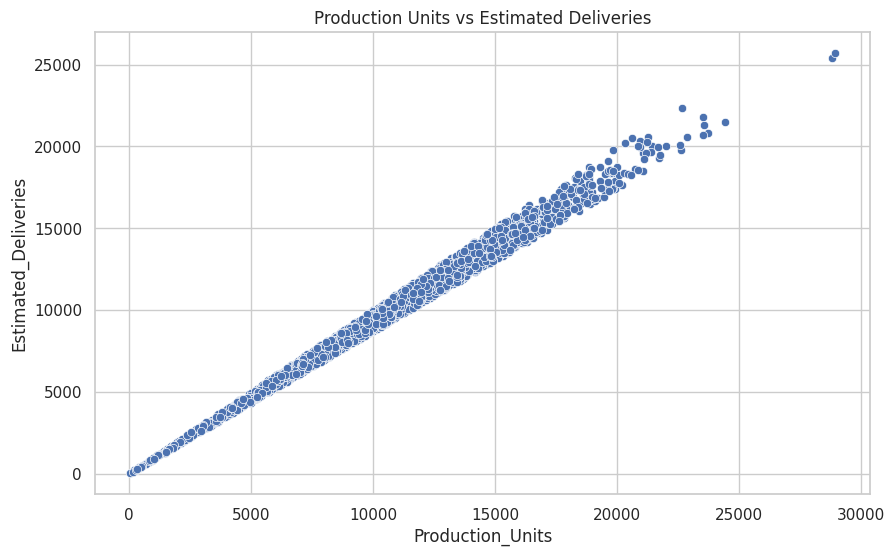

In [32]:
# Production vs Deliveries

plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df_clean,
    x="Production_Units",
    y="Estimated_Deliveries"
)

plt.title("Production Units vs Estimated Deliveries")

plt.show()

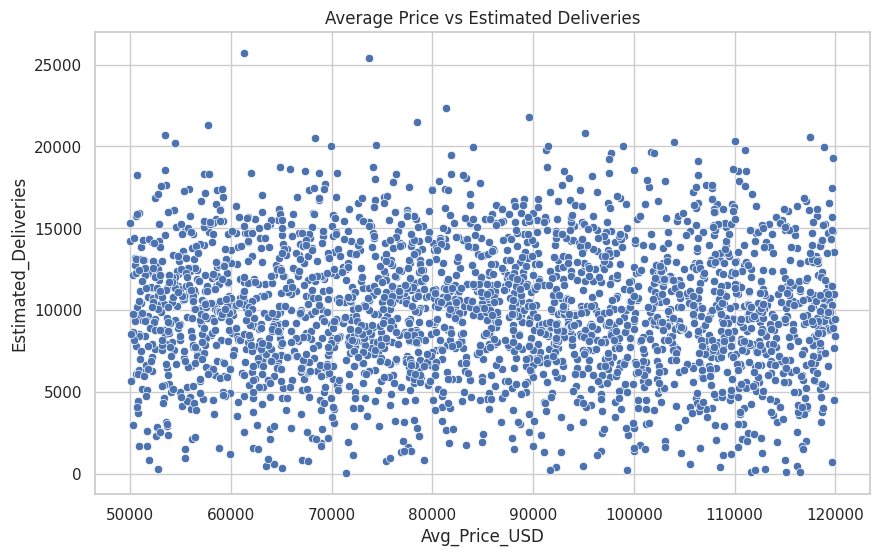

In [33]:
# Price vs Deliveries
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df_clean,
    x="Avg_Price_USD",
    y="Estimated_Deliveries"
)

plt.title("Average Price vs Estimated Deliveries")

plt.show()

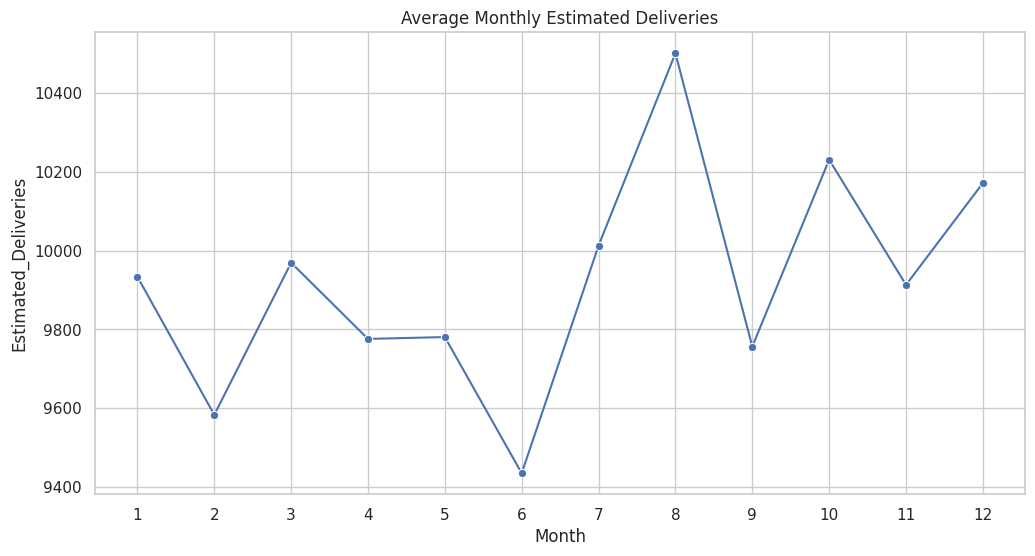

In [34]:
# Monthly Trend
monthly_sales = (
    df_clean
    .groupby("Month")["Estimated_Deliveries"]
    .mean()
    .reset_index()
)

plt.figure(figsize=(12,6))

sns.lineplot(
    data=monthly_sales,
    x="Month",
    y="Estimated_Deliveries",
    marker="o"
)

plt.title("Average Monthly Estimated Deliveries")

plt.xticks(range(1,13))

plt.show()

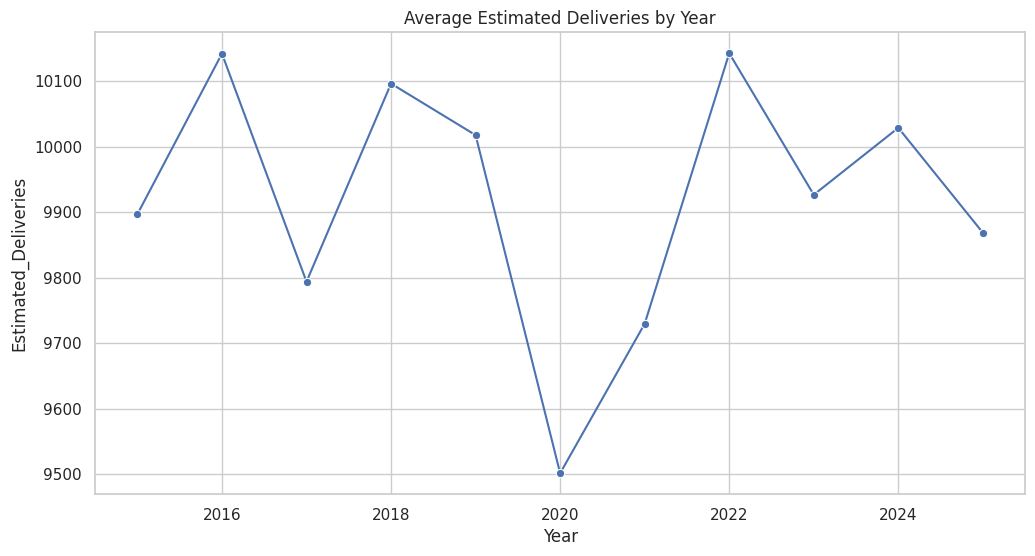

In [35]:
# Yearly Trend
yearly = (
    df_clean
    .groupby("Year")["Estimated_Deliveries"]
    .mean()
    .reset_index()
)

plt.figure(figsize=(12,6))

sns.lineplot(
    data=yearly,
    x="Year",
    y="Estimated_Deliveries",
    marker="o"
)

plt.title("Average Estimated Deliveries by Year")

plt.show()

## EDA Observations

- No missing values were observed.
- Estimated Deliveries follow a moderately distributed pattern.
- Production Units show a positive relationship with Estimated Deliveries.
- Vehicle price appears to have a weaker relationship with deliveries.
- Region and Model influence average deliveries.
- Monthly and yearly trends indicate variation over time.

These insights will be used during feature engineering and model building.

# 6. Feature Engineering

Feature engineering is the process of preparing raw data for machine learning by selecting relevant features, transforming variables, and encoding categorical data.

In this section, we will:
- Separate the target variable from the input features.
- Identify numerical and categorical features.
- Prepare the dataset for machine learning algorithms.

In [37]:
# Separate Features and Target

# Create feature matrix (X)
X = df_clean.drop(columns=["Estimated_Deliveries"])

# Create target variable (y)
y = df_clean["Estimated_Deliveries"]

print("="*50)
print("Feature Matrix Shape :", X.shape)
print("Target Variable Shape:", y.shape)
print("="*50)

print("\nTarget Variable:")
print(y.name)

print("\nFeature Columns:")
print(list(X.columns))

Feature Matrix Shape : (2640, 11)
Target Variable Shape: (2640,)

Target Variable:
Estimated_Deliveries

Feature Columns:
['Year', 'Month', 'Region', 'Model', 'Production_Units', 'Avg_Price_USD', 'Battery_Capacity_kWh', 'Range_km', 'CO2_Saved_tons', 'Source_Type', 'Charging_Stations']


In [38]:
#Identify Feature Types

# Identify numerical features
numerical_features = X.select_dtypes(include=["int64", "float64"]).columns.tolist()

# Identify categorical features
categorical_features = X.select_dtypes(include=["object"]).columns.tolist()

print("=" * 50)
print("Numerical Features")
print("=" * 50)

for feature in numerical_features:
    print(feature)

print("\n")

print("=" * 50)
print("Categorical Features")
print("=" * 50)

for feature in categorical_features:
    print(feature)

print("\n")

print(f"Total Numerical Features   : {len(numerical_features)}")
print(f"Total Categorical Features : {len(categorical_features)}")

Numerical Features
Year
Month
Production_Units
Avg_Price_USD
Battery_Capacity_kWh
Range_km
CO2_Saved_tons
Charging_Stations


Categorical Features
Region
Model
Source_Type


Total Numerical Features   : 8
Total Categorical Features : 3


In [40]:
# One-Hot Encoding

# Apply One-Hot Encoding
X_encoded = pd.get_dummies(
    X,
    columns=categorical_features,
    drop_first=True,
    dtype=int
)

print("=" * 60)
print("Encoded Feature Matrix Shape")
print("=" * 60)

print(X_encoded.shape)

print("\n")

print("First 10 Encoded Columns:")

print(list(X_encoded.columns[:10]))

print("\n")

print("Data Types After Encoding")

display(X_encoded.dtypes.head(15))

Encoded Feature Matrix Shape
(2640, 17)


First 10 Encoded Columns:
['Year', 'Month', 'Production_Units', 'Avg_Price_USD', 'Battery_Capacity_kWh', 'Range_km', 'CO2_Saved_tons', 'Charging_Stations', 'Region_Europe', 'Region_Middle East']


Data Types After Encoding


Year                      int64
Month                     int64
Production_Units          int64
Avg_Price_USD           float64
Battery_Capacity_kWh      int64
Range_km                  int64
CO2_Saved_tons          float64
Charging_Stations         int64
Region_Europe             int64
Region_Middle East        int64
Region_North America      int64
Model_Model 3             int64
Model_Model S             int64
Model_Model X             int64
Model_Model Y             int64
dtype: object

In [41]:
# Train Test Split

from sklearn.model_selection import train_test_split

# Split dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded,
    y,
    test_size=0.20,
    random_state=42
)

print("=" * 60)
print("Training and Testing Dataset Shapes")
print("=" * 60)

print(f"X_train : {X_train.shape}")
print(f"X_test  : {X_test.shape}")
print(f"y_train : {y_train.shape}")
print(f"y_test  : {y_test.shape}")

Training and Testing Dataset Shapes
X_train : (2112, 17)
X_test  : (528, 17)
y_train : (2112,)
y_test  : (528,)


## Feature Engineering Observations

Feature engineering was performed to prepare the dataset for machine learning model development.

### Key Activities Performed

- The target variable **Estimated_Deliveries** was separated from the predictor variables.
- All input features were classified into numerical and categorical variables.
- The dataset contains **8 numerical features** and **3 categorical features**.
- One-Hot Encoding was applied to convert categorical variables (**Region**, **Model**, and **Source_Type**) into numerical representations suitable for regression algorithms.
- After encoding, the number of input features increased from **11** to **17**.
- The processed dataset was divided into training and testing subsets using an **80:20** split.
- The training dataset contains **2,112 observations**, while the testing dataset contains **528 observations**.

### Conclusion

The feature engineering process successfully transformed the dataset into a machine learning-ready format. All predictor variables are now numerical, enabling regression algorithms to learn meaningful relationships from the data. The training and testing datasets are prepared for model development and evaluation.

# Regression Modeling

Regression modeling is performed to predict the **Estimated_Deliveries** using the engineered features.

The following steps will be completed:
- Train a Linear Regression model.
- Generate predictions on the test dataset.
- Evaluate model performance using regression metrics.
- Perform 5-Fold Cross Validation.
- Train a Random Forest Regressor.
- Optimize the Random Forest model using GridSearchCV.
- Compare the performance of both regression models.

In [42]:

#Train Linear Regression Model

from sklearn.linear_model import LinearRegression

linear_model = LinearRegression()

linear_model.fit(X_train, y_train)

print("=" * 60)
print("Linear Regression Model Training")
print("=" * 60)

print("Model trained successfully!")

print("\nModel Information")
print(f"Number of Features Used : {linear_model.n_features_in_}")
print(f"Intercept               : {linear_model.intercept_:.2f}")

Linear Regression Model Training
Model trained successfully!

Model Information
Number of Features Used : 17
Intercept               : -86.75


In [43]:
# Generate Predictions
y_pred = linear_model.predict(X_test)

print("=" * 60)
print("Prediction Summary")
print("=" * 60)

print(f"Total Predictions Generated : {len(y_pred)}")

prediction_df = pd.DataFrame({
    "Actual_Deliveries": y_test.values,
    "Predicted_Deliveries": y_pred
})

print("\nFirst 10 Predictions")

display(prediction_df.head(10))

Prediction Summary
Total Predictions Generated : 528

First 10 Predictions


,Actual_Deliveries,Predicted_Deliveries
0,6991,7571.600001
1,9326,9433.894739
2,9061,8799.017879
3,8951,9366.321985
4,8707,8922.602152
5,11351,11482.734133
6,14193,14204.708820
7,15156,14341.476516
8,9915,10003.073096
9,7642,7858.434135


In [44]:
# Step 7.3 - Evaluate Linear Regression Model
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = mse ** 0.5
r2 = r2_score(y_test, y_pred)

print("=" * 60)
print("Linear Regression Evaluation Metrics")
print("=" * 60)

print(f"Mean Absolute Error (MAE)      : {mae:.2f}")
print(f"Mean Squared Error (MSE)       : {mse:.2f}")
print(f"Root Mean Squared Error (RMSE) : {rmse:.2f}")
print(f"R² Score                       : {r2:.4f}")

Linear Regression Evaluation Metrics
Mean Absolute Error (MAE)      : 309.70
Mean Squared Error (MSE)       : 147478.36
Root Mean Squared Error (RMSE) : 384.03
R² Score                       : 0.9901


In [45]:
#  5-Fold Cross Validation

from sklearn.model_selection import cross_val_score
import numpy as np

cv_scores = cross_val_score(
    estimator=linear_model,
    X=X_encoded,
    y=y,
    cv=5,
    scoring="r2"
)

print("=" * 60)
print("5-Fold Cross Validation Results")
print("=" * 60)

print("Individual R² Scores:")

for i, score in enumerate(cv_scores, start=1):
    print(f"Fold {i}: {score:.4f}")

print("\nAverage R² Score :", round(np.mean(cv_scores), 4))
print("Standard Deviation:", round(np.std(cv_scores), 4))

5-Fold Cross Validation Results
Individual R² Scores:
Fold 1: 0.9906
Fold 2: 0.9904
Fold 3: 0.9892
Fold 4: 0.9903
Fold 5: 0.9906

Average R² Score : 0.9902
Standard Deviation: 0.0005


In [46]:
# Train Random Forest Regressor

from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

print("=" * 60)
print("Random Forest Regressor Training")
print("=" * 60)

print("Model trained successfully!")

print("\nModel Information")
print(f"Number of Trees    : {rf_model.n_estimators}")
print(f"Random State       : {rf_model.random_state}")
print(f"Features Used      : {rf_model.n_features_in_}")

Random Forest Regressor Training
Model trained successfully!

Model Information
Number of Trees    : 100
Random State       : 42
Features Used      : 17


In [47]:
#  Random Forest Prediction & Evaluation
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)
rf_predictions = rf_model.predict(X_test)

rf_mae = mean_absolute_error(y_test, rf_predictions)
rf_mse = mean_squared_error(y_test, rf_predictions)
rf_rmse = rf_mse ** 0.5
rf_r2 = r2_score(y_test, rf_predictions)

print("=" * 60)
print("Random Forest Evaluation Metrics")
print("=" * 60)

print(f"Mean Absolute Error (MAE)      : {rf_mae:.2f}")
print(f"Mean Squared Error (MSE)       : {rf_mse:.2f}")
print(f"Root Mean Squared Error (RMSE) : {rf_rmse:.2f}")
print(f"R² Score                       : {rf_r2:.4f}")

Random Forest Evaluation Metrics
Mean Absolute Error (MAE)      : 321.23
Mean Squared Error (MSE)       : 164310.31
Root Mean Squared Error (RMSE) : 405.35
R² Score                       : 0.9890


In [48]:
# Hyperparameter Tuning

from sklearn.model_selection import GridSearchCV

param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [10, 20, None],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2]
}

grid_search = GridSearchCV(
    estimator=RandomForestRegressor(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print("=" * 60)
print("Grid Search Completed")
print("=" * 60)

print("Best Parameters:")
print(grid_search.best_params_)

print("\nBest Cross Validation R² Score:")
print(round(grid_search.best_score_, 4))

Grid Search Completed
Best Parameters:
{'max_depth': 20, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}

Best Cross Validation R² Score:
0.9888


In [51]:
# Optimized Random Forest Model

best_rf_model = grid_search.best_estimator_
best_rf_predictions = best_rf_model.predict(X_test)
best_rf_mae = mean_absolute_error(y_test, best_rf_predictions)
best_rf_mse = mean_squared_error(y_test, best_rf_predictions)
best_rf_rmse = best_rf_mse ** 0.5
best_rf_r2 = r2_score(y_test, best_rf_predictions)

print("=" * 60)
print("Optimized Random Forest Evaluation")
print("=" * 60)

print(f"MAE  : {best_rf_mae:.2f}")
print(f"MSE  : {best_rf_mse:.2f}")
print(f"RMSE : {best_rf_rmse:.2f}")
print(f"R²   : {best_rf_r2:.4f}")

Optimized Random Forest Evaluation
MAE  : 319.99
MSE  : 163487.61
RMSE : 404.34
R²   : 0.9890


In [52]:
#Model Comparison
comparison_df = pd.DataFrame({
    "Metric": ["MAE", "MSE", "RMSE", "R² Score"],
    "Linear Regression": [
        round(mae, 2),
        round(mse, 2),
        round(rmse, 2),
        round(r2, 4)
    ],
    "Random Forest": [
        round(rf_mae, 2),
        round(rf_mse, 2),
        round(rf_rmse, 2),
        round(rf_r2, 4)
    ],
    "Optimized Random Forest": [
        round(best_rf_mae, 2),
        round(best_rf_mse, 2),
        round(best_rf_rmse, 2),
        round(best_rf_r2, 4)
    ]
})

print("Model Performance Comparison")
display(comparison_df)

Model Performance Comparison


,Metric,Linear Regression,Random Forest,Optimized Random Forest
0,MAE,309.7000,321.230,319.990
1,MSE,147478.3600,164310.310,163487.610
2,RMSE,384.0300,405.350,404.340
3,R² Score,0.9901,0.989,0.989


## Regression Modeling Observations

Regression models were developed and evaluated to predict **Estimated_Deliveries** using the engineered features.

### Models Evaluated

- Linear Regression
- Random Forest Regressor
- Optimized Random Forest (GridSearchCV)

### Key Findings

- The **Linear Regression** model achieved the best overall predictive performance with:
  - **MAE:** 309.70
  - **RMSE:** 384.03
  - **R² Score:** 0.9901
- Five-Fold Cross Validation produced an average **R² Score of 0.9902** with a **standard deviation of 0.0005**, indicating consistent performance across different data splits.
- The Random Forest Regressor was trained using default hyperparameters and further optimized using **GridSearchCV**.
- GridSearchCV identified the following optimal hyperparameters:
  - `n_estimators = 200`
  - `max_depth = 20`
  - `min_samples_split = 2`
  - `min_samples_leaf = 1`
- The optimized Random Forest model achieved a slight improvement over the default Random Forest but did not outperform the Linear Regression model.

### Conclusion

The regression analysis demonstrates that **Linear Regression** is the most suitable model for this dataset. The excellent R² score and low prediction errors indicate that the relationship between the selected features and **Estimated_Deliveries** is predominantly linear. Therefore, Linear Regression was selected as the final predictive model.

# 8. Time Series Forecasting

Time Series Forecasting is performed to analyze historical delivery trends over time and prepare the dataset for forecasting future values.

The following steps will be completed:
- Create a proper datetime column.
- Aggregate deliveries by month.
- Perform the Augmented Dickey-Fuller (ADF) Test.
- Check stationarity of the time series.
- Generate a simple forecast.
- Present the forecast results in a tabular format.

In [54]:
# Create Date Column
df_time = df_clean.copy()

df_time["Date"] = pd.to_datetime(
    dict(
        year=df_time["Year"],
        month=df_time["Month"],
        day=1
    )
)

df_time = df_time.sort_values("Date")

print("=" * 60)
print("Date Column Created Successfully")
print("=" * 60)

display(
    df_time[
        ["Year", "Month", "Date", "Estimated_Deliveries"]
    ].head(10)
)

Date Column Created Successfully


,Year,Month,Date,Estimated_Deliveries
872,2015,1,2015-01-01,12446
2354,2015,1,2015-01-01,11446
2312,2015,1,2015-01-01,8803
2293,2015,1,2015-01-01,6367
2215,2015,1,2015-01-01,8795
2065,2015,1,2015-01-01,2161
2023,2015,1,2015-01-01,11986
1872,2015,1,2015-01-01,8833
2469,2015,1,2015-01-01,9446
1766,2015,1,2015-01-01,4350


In [55]:
#  Monthly Time Series Aggregation
monthly_deliveries = (
    df_time
    .groupby("Date")["Estimated_Deliveries"]
    .sum()
    .reset_index()
)

print("=" * 60)
print("Monthly Time Series Created")
print("=" * 60)

print(f"Number of Monthly Records : {len(monthly_deliveries)}")

display(monthly_deliveries.head(12))

Monthly Time Series Created
Number of Monthly Records : 132


,Date,Estimated_Deliveries
0,2015-01-01,183180
1,2015-02-01,165053
2,2015-03-01,184567
3,2015-04-01,225623
4,2015-05-01,184264
5,2015-06-01,198787
6,2015-07-01,177759
7,2015-08-01,214223
8,2015-09-01,188448
9,2015-10-01,221541


In [56]:

#  Augmented Dickey-Fuller Test

from statsmodels.tsa.stattools import adfuller


adf_result = adfuller(monthly_deliveries["Estimated_Deliveries"])

print("=" * 60)
print("Augmented Dickey-Fuller (ADF) Test")
print("=" * 60)

print(f"ADF Statistic : {adf_result[0]:.4f}")
print(f"p-value       : {adf_result[1]:.4f}")
print(f"Lags Used     : {adf_result[2]}")
print(f"Observations  : {adf_result[3]}")

print("\nCritical Values:")

for key, value in adf_result[4].items():
    print(f"{key}: {value:.4f}")


print("\nConclusion:")

if adf_result[1] < 0.05:
    print("The time series is Stationary.")
else:
    print("The time series is Non-Stationary.")

Augmented Dickey-Fuller (ADF) Test
ADF Statistic : -8.8810
p-value       : 0.0000
Lags Used     : 1
Observations  : 130

Critical Values:
1%: -3.4817
5%: -2.8840
10%: -2.5788

Conclusion:
The time series is Stationary.


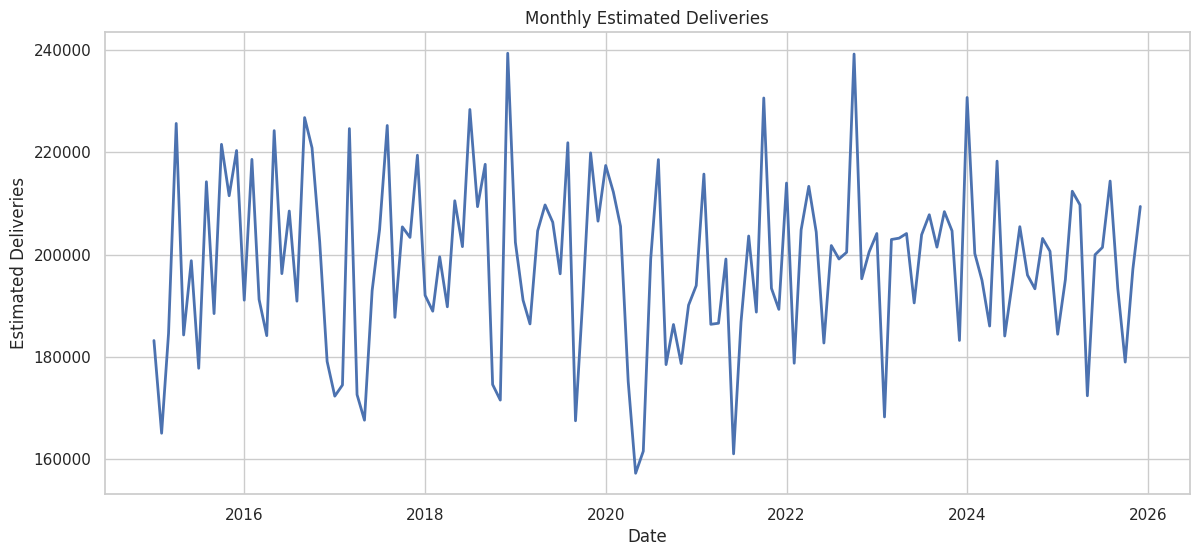

In [57]:
# Monthly Deliveries Time Series

plt.figure(figsize=(14,6))

plt.plot(
    monthly_deliveries["Date"],
    monthly_deliveries["Estimated_Deliveries"],
    linewidth=2
)

plt.title("Monthly Estimated Deliveries")
plt.xlabel("Date")
plt.ylabel("Estimated Deliveries")

plt.grid(True)

plt.show()

In [58]:

# Exponential Smoothing Forecast

from statsmodels.tsa.holtwinters import ExponentialSmoothing

forecast_model = ExponentialSmoothing(
    monthly_deliveries["Estimated_Deliveries"],
    trend="add",
    seasonal="add",
    seasonal_periods=12
)

forecast_fit = forecast_model.fit()
forecast = forecast_fit.forecast(12)

forecast_dates = pd.date_range(
    start=monthly_deliveries["Date"].iloc[-1] + pd.DateOffset(months=1),
    periods=12,
    freq="MS"
)

forecast_df = pd.DataFrame({
    "Forecast_Date": forecast_dates,
    "Forecasted_Deliveries": forecast.values
})

print("=" * 60)
print("Next 12-Month Forecast")
print("=" * 60)

display(forecast_df)

Next 12-Month Forecast


,Forecast_Date,Forecasted_Deliveries
0,2026-01-01,192503.413088
1,2026-02-01,190435.129208
2,2026-03-01,198070.502476
3,2026-04-01,189794.124276
4,2026-05-01,197737.023790
5,2026-06-01,192220.156886
6,2026-07-01,201206.012233
7,2026-08-01,208206.054814
8,2026-09-01,198374.685638
9,2026-10-01,203016.972600


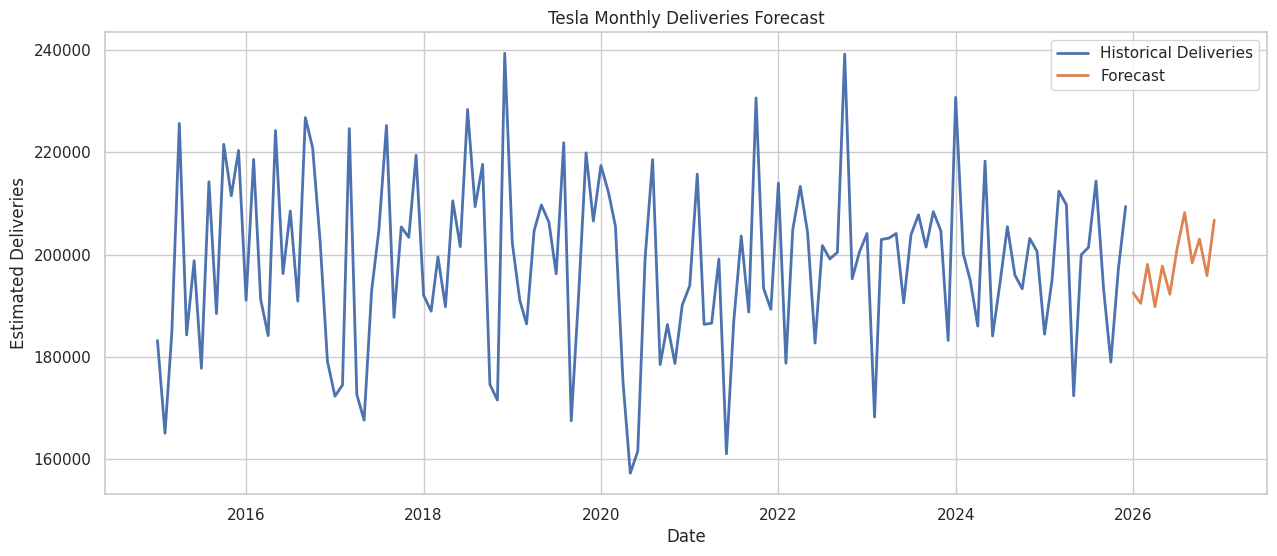

In [60]:
# Forecast Visualization

plt.figure(figsize=(15,6))

plt.plot(
    monthly_deliveries["Date"],
    monthly_deliveries["Estimated_Deliveries"],
    label="Historical Deliveries",
    linewidth=2
)

plt.plot(
    forecast_df["Forecast_Date"],
    forecast_df["Forecasted_Deliveries"],
    label="Forecast",
    linewidth=2
)

plt.title("Tesla Monthly Deliveries Forecast")

plt.xlabel("Date")
plt.ylabel("Estimated Deliveries")

plt.legend()

plt.grid(True)

plt.show()

## Time Series Forecasting Observations

Time series forecasting was performed using the monthly aggregated delivery data.

### Key Activities Performed

- A datetime column was created from the Year and Month features.
- Monthly estimated deliveries were aggregated into a single time series containing **132 monthly observations**.
- The Augmented Dickey-Fuller (ADF) test was performed to evaluate stationarity.
- The ADF statistic was **-8.8810** with a **p-value of 0.0000**, indicating that the time series is stationary.
- Since the series is stationary, no differencing or additional transformations were required.
- A Holt-Winters Exponential Smoothing model was trained to forecast future monthly deliveries.
- Forecasts for the next **12 months** were generated and visualized alongside the historical data.

### Conclusion

The time series analysis confirms that the historical delivery data is stationary and suitable for forecasting. The Exponential Smoothing model provides a simple and interpretable approach for predicting future monthly deliveries, completing the end-to-end machine learning pipeline from data preprocessing to forecasting.